# Side-by-side Embeddings

Left: Bone marrow cells in DC2 vs DC3 (diffusion components).  
Right: Pancreas cells in UMAP.  

Both coloured by cell-type cluster; root cell highlighted with a gold star.

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import scanpy as sc

TRAVELER_ROOT = Path(os.environ.get('TRAVELER_ROOT', Path().resolve().parents[0]))
DATA_DIR = TRAVELER_ROOT / 'data'
print('Data dir:', DATA_DIR)

Data dir: /Users/Abhi/Desktop/TraVeLer/data


## Bone marrow — preprocess & compute diffusion map

In [2]:
bm = sc.read(str(DATA_DIR / 'setty_bone_marrow.h5ad'))
print(f'Bone marrow: {bm.n_obs} cells, {bm.n_vars} genes')
print('Cluster labels:', bm.obs['clusters'].value_counts().to_dict())

Bone marrow: 5780 cells, 27876 genes
Cluster labels: {'HSC_1': 1118, 'HSC_2': 984, 'Ery_1': 742, 'Mono_1': 724, 'Precursors': 666, 'CLP': 488, 'Mono_2': 429, 'DCs': 303, 'Ery_2': 265, 'Mega': 61}


In [3]:
np.random.seed(42)

sc.pp.filter_genes(bm, min_counts=20)
sc.pp.normalize_total(bm)
sc.pp.log1p(bm)
sc.pp.highly_variable_genes(bm)

sc.tl.pca(bm)
sc.pp.neighbors(bm, n_neighbors=50, n_pcs=10)
sc.tl.diffmap(bm, n_comps=10)

print('Diffusion map shape:', bm.obsm['X_diffmap'].shape)

/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Diffusion map shape: (5780, 10)


In [4]:
# Root cell: argmin of DC4 (index 3) — separates HSCs from committed progenitors
bm_root = int(bm.obsm['X_diffmap'][:, 3].argmin())
print(f'Bone marrow root cell index: {bm_root}')
print(f'Root cell cluster: {bm.obs["clusters"].iloc[bm_root]}')

Bone marrow root cell index: 2276
Root cell cluster: HSC_1


## Pancreas — load (UMAP already stored in the file)

In [5]:
pan = sc.read(str(DATA_DIR / 'pancreas.h5ad'))
print(f'Pancreas: {pan.n_obs} cells, {pan.n_vars} genes')
print('Cluster labels:', pan.obs['clusters'].value_counts().to_dict())
print('UMAP shape:', pan.obsm['X_umap'].shape)

Pancreas: 3696 cells, 27998 genes
Cluster labels: {'Ductal': 916, 'Ngn3 high EP': 642, 'Pre-endocrine': 592, 'Beta': 591, 'Alpha': 481, 'Ngn3 low EP': 262, 'Epsilon': 142, 'Delta': 70}
UMAP shape: (3696, 2)


/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [6]:
# Root cell: left-half UMAP (x < mean x), highest y — selects a Ductal progenitor
umap = pan.obsm['X_umap']
mask = umap[:, 0] < umap[:, 0].mean()
passed = np.where(mask)[0]
pan_root = int(passed[umap[mask, 1].argmax()])
print(f'Pancreas root cell index: {pan_root}')
print(f'Root cell cluster: {pan.obs["clusters"].iloc[pan_root]}')

Pancreas root cell index: 1103
Root cell cluster: Ductal


## Side-by-side plot

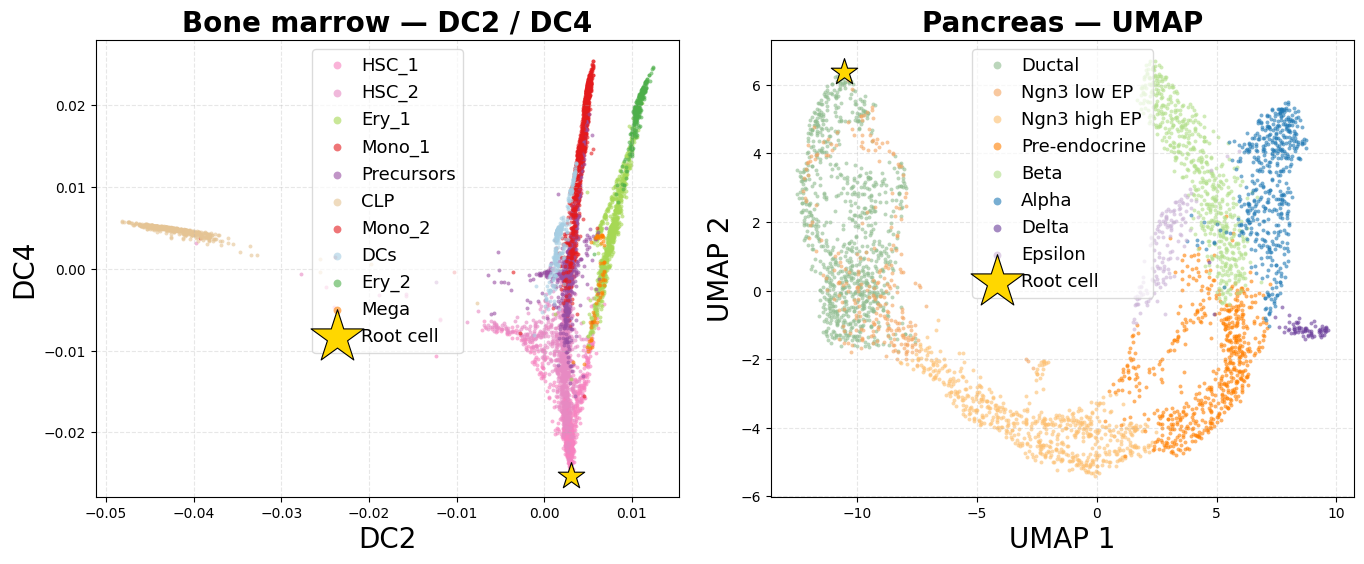

Saved side_by_side_embeddings.png


In [11]:
# ── colour palettes from the uns stored in each object ──────────────────────
bm_palette = dict(zip(
    bm.obs['clusters'].cat.categories,
    bm.uns.get('clusters_colors', plt.cm.tab10.colors)
))
pan_palette = dict(zip(
    pan.obs['clusters'].cat.categories,
    pan.uns.get('clusters_colors', plt.cm.tab10.colors)
))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── LEFT: Bone marrow DC2 vs DC3 ────────────────────────────────────────────
ax = axes[0]
dc2 = bm.obsm['X_diffmap'][:, 1]
dc4 = bm.obsm['X_diffmap'][:, 3]

for cluster in bm.obs['clusters'].cat.categories:
    sel = bm.obs['clusters'] == cluster
    ax.scatter(
        dc2[sel], dc4[sel],
        c=bm_palette[cluster],
        s=8, alpha=0.6, linewidths=0,
        label=cluster, rasterized=True
    )

# Root cell
ax.scatter(
    dc2[bm_root], dc4[bm_root],
    marker='*', s=400, c='gold',
    edgecolors='black', linewidths=0.8, zorder=10,
    label='Root cell'
)

ax.set_xlabel('DC2', fontsize=20)
ax.set_ylabel('DC4', fontsize=20)
ax.set_title('Bone marrow — DC2 / DC4', fontsize=20, fontweight='bold')
ax.legend(markerscale=2, fontsize=13, framealpha=0.7,
          loc='best', handletextpad=0.3)
ax.grid(True, linestyle='--', alpha=0.3)

# ── RIGHT: Pancreas UMAP ────────────────────────────────────────────────────
ax = axes[1]
u1 = pan.obsm['X_umap'][:, 0]
u2 = pan.obsm['X_umap'][:, 1]

for cluster in pan.obs['clusters'].cat.categories:
    sel = pan.obs['clusters'] == cluster
    ax.scatter(
        u1[sel], u2[sel],
        c=pan_palette[cluster],
        s=8, alpha=0.6, linewidths=0,
        label=cluster, rasterized=True
    )

# Root cell
ax.scatter(
    u1[pan_root], u2[pan_root],
    marker='*', s=400, c='gold',
    edgecolors='black', linewidths=0.8, zorder=10,
    label='Root cell'
)

ax.set_xlabel('UMAP 1', fontsize=20)
ax.set_ylabel('UMAP 2', fontsize=20)
ax.set_title('Pancreas — UMAP', fontsize=20, fontweight='bold')
ax.legend(markerscale=2, fontsize=13, framealpha=0.7,
          loc='best', handletextpad=0.3)
ax.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout(pad=2.0)
plt.savefig('side_by_side_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved side_by_side_embeddings.png')